# PCA Analysis: Gemma-2-27b Assistant Axis

Sanity check that the assistant axis exists in gemma-2-27b.
Runs PCA on role vectors and examines the top PCs.

In [131]:
import sys
sys.path.insert(0, '../assistant-axis')

import torch
import numpy as np
from pathlib import Path
from huggingface_hub import snapshot_download
from huggingface_hub.utils import disable_progress_bars

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from assistant_axis import compute_pca, MeanScaler

disable_progress_bars()

## Configuration

In [132]:
# Model configuration
MODEL_NAME = "gemma-2-27b"
TARGET_LAYER = 35  # Layer where refusal direction was selected (pos=-1, layer=35)

# HuggingFace configuration for pre-computed vectors
REPO_ID = "lu-christina/assistant-axis-vectors"

## Load Data

In [133]:
print(f"Loading from HuggingFace: {REPO_ID}")

# Download all vectors for this model
local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=[f"{MODEL_NAME}/role_vectors/*.pt", f"{MODEL_NAME}/default_vector.pt"]
)

# Load role vectors
role_vectors = {p.stem: torch.load(p, map_location="cpu", weights_only=False)
                for p in Path(local_dir, MODEL_NAME, "role_vectors").glob("*.pt")}
print(f"Loaded {len(role_vectors)} role vectors")

# Load default vector
default_vector = torch.load(Path(local_dir, MODEL_NAME, "default_vector.pt"), map_location="cpu", weights_only=False)
print(f"Default vector shape: {default_vector.shape}")

Loading from HuggingFace: lu-christina/assistant-axis-vectors
Loaded 275 role vectors
Default vector shape: torch.Size([46, 4608])


## Run PCA

In [134]:
# Stack role vectors at target layer
role_vectors_at_layer = torch.stack([v[TARGET_LAYER] for v in role_vectors.values()]).float()
role_labels = list(role_vectors.keys())

# Run PCA with mean centering
scaler = MeanScaler()
pca_transformed, variance_explained, n_components, pca, scaler = compute_pca(
    role_vectors_at_layer,
    layer=None,
    scaler=scaler
)
print(f"Fitted PCA with {len(variance_explained)} components")

PCA fitted with 275 components
Cumulative variance for first 5 components: [0.21617071 0.3520819  0.40956262 0.4609739  0.50021684]

PCA Analysis Results:
Elbow point at component: 3
Dimensions for 70% variance: 17
Dimensions for 80% variance: 31
Dimensions for 90% variance: 62
Dimensions for 95% variance: 98
Fitted PCA with 275 components


## Plot variance explained

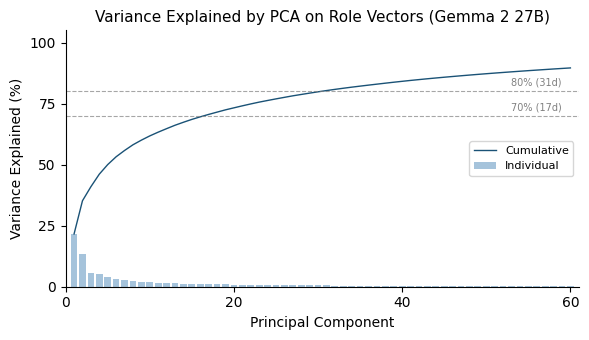

In [135]:
def plot_variance_explained(ax, variance_explained, title, max_components=60, show_ylabel=True):
    """Plot variance explained (histogram + cumulative line)."""
    n_show = min(len(variance_explained), max_components)
    var_exp = variance_explained[:n_show]
    cumulative = np.cumsum(var_exp)
    components = np.arange(1, n_show + 1)

    bar_color = '#6a9bc3'
    line_color = '#1a5276'

    ax.bar(components, var_exp * 100, width=0.8, color=bar_color, alpha=0.6,
           edgecolor='none', label='Individual')
    ax.plot(components, cumulative * 100, color=line_color, linewidth=1, label='Cumulative')

    for thresh in [70, 80, 90]:
        idx = np.argmax(cumulative >= thresh / 100.0)
        if cumulative[idx] >= thresh / 100.0:
            n_dims = idx + 1
            ax.axhline(y=thresh, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.text(max_components - 1, thresh + 1.5, f'{thresh}% ({n_dims}d)',
                    fontsize=7, color='gray', ha='right', va='bottom')

    ax.set_xlim(0, max_components + 1)
    ax.set_ylim(0, 105)
    ax.set_xlabel('Principal Component')
    if show_ylabel:
        ax.set_ylabel('Variance Explained (%)')
    ax.set_title(title, fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.legend(loc='center right', fontsize=8)

fig, ax = plt.subplots(figsize=(6, 3.5))
plot_variance_explained(ax, variance_explained, f"Variance Explained by PCA on Role Vectors ({MODEL_NAME.replace('-', ' ').title()})", max_components=60)
plt.tight_layout()
plt.show()

## Cosine Similarity with Top 3 PCs

In [136]:
def plot_pc_lines(role_cosine_sims, role_labels, default_cosine_sims=None,
                       figsize=(8, 7), n_extremes=5, show_histogram=True):
    """
    Plot top 3 PCs' cosine similarities in a single figure with 3 subplots.
    """
    custom_cmap = LinearSegmentedColormap.from_list('PurpleTeal', ['#9b59b6', '#1abc9c'])

    fig, axes = plt.subplots(3, 1, figsize=figsize)

    for pc_idx, ax in enumerate(axes):
        projections = role_cosine_sims[:, pc_idx]

        c_norm = (projections + 1) / 2
        colors = custom_cmap(c_norm)

        sorted_indices = np.argsort(projections)
        low_indices = sorted_indices[:n_extremes].tolist()
        high_indices = sorted_indices[-n_extremes:][::-1].tolist()

        y_pos = np.zeros_like(projections)
        ax.scatter(projections, y_pos, c=colors, marker='o', s=40, alpha=0.6, edgecolors='none', zorder=3)

        if show_histogram:
            hist_counts, bin_edges = np.histogram(projections, bins=30, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            bin_width = bin_edges[1] - bin_edges[0]
            scaled_heights = hist_counts * 0.4
            bin_norm = (bin_centers + 1) / 2
            bin_colors = custom_cmap(np.clip(bin_norm, 0, 1))
            ax.bar(bin_centers, scaled_heights, width=bin_width, alpha=0.3, color=bin_colors, edgecolor='none', zorder=1)

        if default_cosine_sims is not None:
            val = default_cosine_sims[pc_idx]
            ax.axvline(x=val, color='blue', linestyle='--', linewidth=1, alpha=0.9, zorder=2)
            ax.scatter([val], [0], c='blue', marker='*', s=300, alpha=1.0, zorder=5)
            ax.text(val, 0.55, 'Default Response', ha='center', va='bottom', fontsize=10, color='blue', alpha=0.9)

        y_above = [0.25, 0.35, 0.45]
        y_below = [-0.25, -0.35, -0.45]

        for i, idx in enumerate(low_indices):
            label = role_labels[idx].replace('_', ' ').title()
            x_pos = projections[idx]
            if i % 2 == 0:
                y_label = y_above[min(i // 2, len(y_above) - 1)]
                va = 'bottom'
            else:
                y_label = y_below[min(i // 2, len(y_below) - 1)]
                va = 'top'
            line_end = y_label - 0.02 if y_label > 0 else y_label + 0.02
            ax.plot([x_pos, x_pos], [0.02 if y_label > 0 else -0.02, line_end], '-', color='gray', alpha=0.4, linewidth=0.8, zorder=1)
            ax.text(x_pos, y_label, label, ha='center', va=va, fontsize=9, zorder=4)

        for i, idx in enumerate(high_indices):
            label = role_labels[idx].replace('_', ' ').title()
            x_pos = projections[idx]
            if i % 2 == 0:
                y_label = y_above[min(i // 2, len(y_above) - 1)]
                va = 'bottom'
            else:
                y_label = y_below[min(i // 2, len(y_below) - 1)]
                va = 'top'
            line_end = y_label - 0.02 if y_label > 0 else y_label + 0.02
            ax.plot([x_pos, x_pos], [0.02 if y_label > 0 else -0.02, line_end], '-', color='gray', alpha=0.4, linewidth=0.8, zorder=1)
            ax.text(x_pos, y_label, label, ha='center', va=va, fontsize=9, zorder=4)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_position('zero')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=2, zorder=1)
        ax.tick_params(axis='x', length=12, width=1.5, pad=10)
        ax.tick_params(axis='y', length=0, width=0)
        ax.set_yticks([])
        ax.set_xticks([-0.8, -0.4, 0, 0.4, 0.8])
        ax.set_ylim(-0.55, 0.6)
        ax.set_xlim(-1, 1)
        ax.grid(False)
        ax.set_title(f'PC{pc_idx + 1}', fontsize=12, fontweight='bold', loc='left')

    plt.tight_layout()
    return fig

cos(PC1, assistant_axis) at layer 35: -0.7314
  (positive = aligned, negative = flipped)

Top 5 by assistant axis:
                  assistant: 0.8950
                 instructor: 0.7426
                  validator: 0.7205
                 consultant: 0.7149
                     doctor: 0.7100
Bottom 5:
                   narrator: -0.6018
                   wanderer: -0.5851
                    prophet: -0.5690
                      ghost: -0.5506
                     hermit: -0.5435


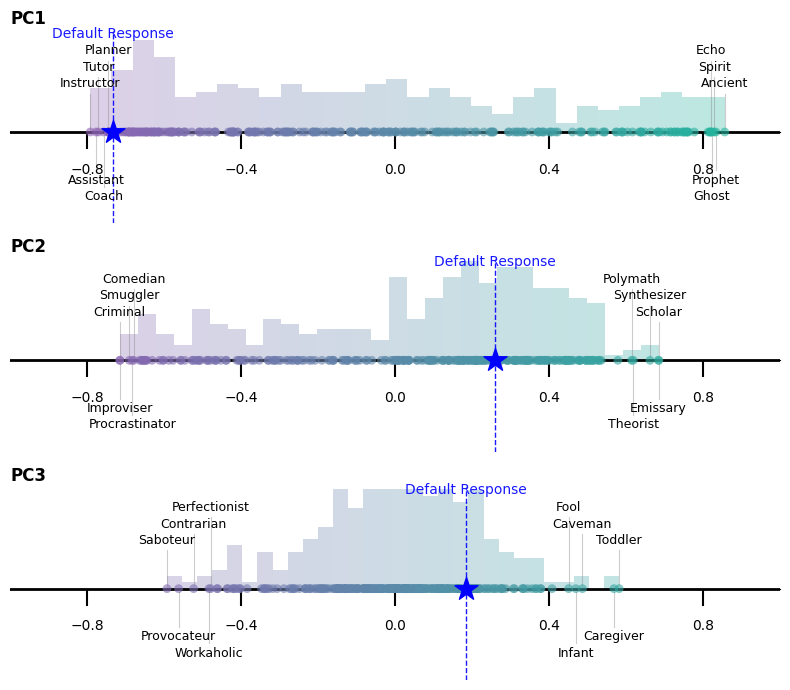

In [137]:
# Get top 3 PC directions (normalized)
pc_directions = pca.components_[:3]
pc_directions = pc_directions / np.linalg.norm(pc_directions, axis=1, keepdims=True)

# Scale and normalize role vectors
role_vectors_scaled = scaler.transform(role_vectors_at_layer.numpy())
role_vectors_norm = role_vectors_scaled / np.linalg.norm(role_vectors_scaled, axis=1, keepdims=True)

# Compute cosine similarities with PC directions: (n_roles, 3)
role_cosine_sims = role_vectors_norm @ pc_directions.T

# Scale and normalize default vector
default_at_layer = default_vector[TARGET_LAYER].float().numpy().reshape(1, -1)
default_scaled = scaler.transform(default_at_layer)
default_norm = default_scaled / np.linalg.norm(default_scaled)

# Compute default vector cosine similarities with PCs
default_cosine_sims = (default_norm @ pc_directions.T)[0]

# Load actual assistant axis (PC1 may not align with it at deeper layers)
aa_data = torch.load("../vectors/gemma-2-27b-it/assistant_axis.pt", map_location="cpu", weights_only=False)
if isinstance(aa_data, dict):
    assistant_axis = aa_data["axis"][TARGET_LAYER].float().numpy()
else:
    assistant_axis = aa_data[TARGET_LAYER].float().numpy()
assistant_axis_normed = assistant_axis / np.linalg.norm(assistant_axis)

# Cosine similarity of each role vector with the actual assistant axis
role_aa_cosine_sims = role_vectors_norm @ assistant_axis_normed.reshape(-1, 1)
role_aa_cosine_sims = role_aa_cosine_sims.flatten()

# Check PC1-assistant axis alignment
cos_pc1_aa = np.dot(pc_directions[0], assistant_axis_normed)
print(f"cos(PC1, assistant_axis) at layer {TARGET_LAYER}: {cos_pc1_aa:.4f}")
print(f"  (positive = aligned, negative = flipped)")

# Show top/bottom roles by assistant axis
sorted_aa = np.argsort(role_aa_cosine_sims)
print(f"\nTop 5 by assistant axis:")
for i in sorted_aa[-5:][::-1]:
    print(f"  {role_labels[i]:>25s}: {role_aa_cosine_sims[i]:.4f}")
print(f"Bottom 5:")
for i in sorted_aa[:5]:
    print(f"  {role_labels[i]:>25s}: {role_aa_cosine_sims[i]:.4f}")

# Plot
fig = plot_pc_lines(
    role_cosine_sims,
    role_labels,
    default_cosine_sims=default_cosine_sims,
    figsize=(8, 7),
    n_extremes=5,
    show_histogram=True
)
plt.show()

## PCA Scatter Plot (PC1 vs PC2)

2D projection of role vectors, with the default vector highlighted.

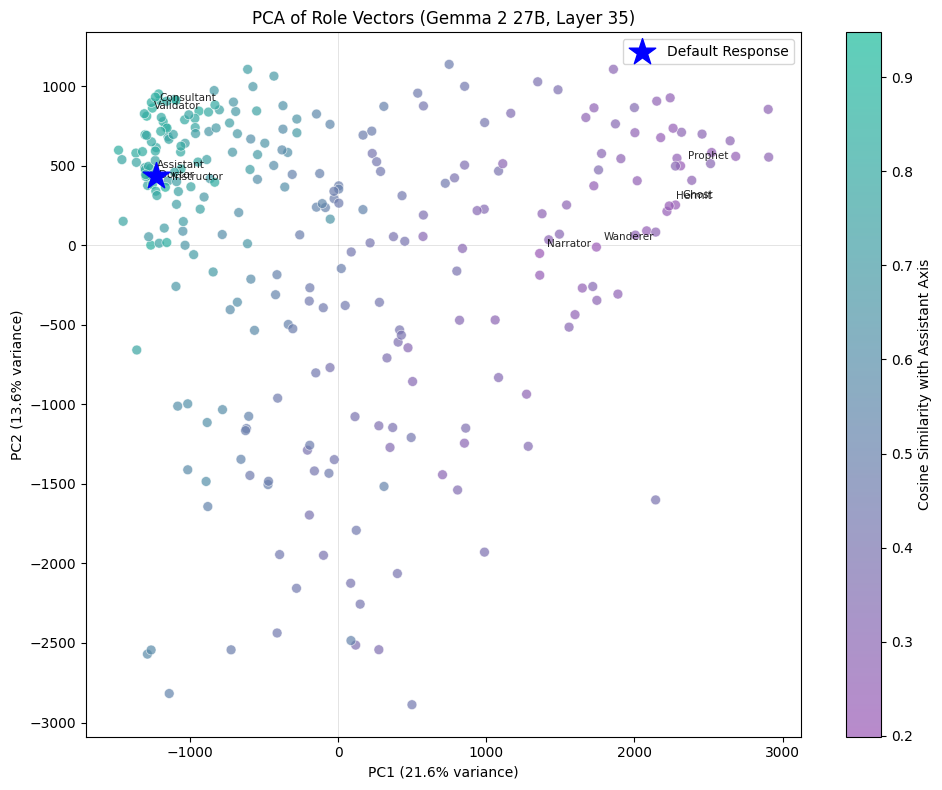

In [138]:
# Project default vector into PCA space
default_2d = pca.transform(default_scaled)[0]

# Color by cosine similarity with actual assistant axis (not PC1)
custom_cmap = LinearSegmentedColormap.from_list('PurpleTeal', ['#9b59b6', '#1abc9c'])
c_norm = (role_aa_cosine_sims + 1) / 2

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                c=c_norm, cmap=custom_cmap,
                s=50, alpha=0.7, edgecolors='white', linewidth=0.5, zorder=3)

# Default vector
ax.scatter(default_2d[0], default_2d[1], c='blue', marker='*', s=400, zorder=5, label='Default Response')

# Label extremes by assistant axis (not PC1)
sorted_by_aa = np.argsort(role_aa_cosine_sims)
for idx in list(sorted_by_aa[:5]) + list(sorted_by_aa[-5:]):
    label = role_labels[idx].replace('_', ' ').title()
    ax.annotate(label, xy=(pca_transformed[idx, 0], pca_transformed[idx, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7.5, alpha=0.85, zorder=4)

plt.colorbar(sc, ax=ax, label='Cosine Similarity with Assistant Axis')
ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%} variance)')
ax.set_title(f'PCA of Role Vectors ({MODEL_NAME.replace("-", " ").title()}, Layer {TARGET_LAYER})')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Crescendo Attack Trajectory in PCA Space

Project per-turn decision-point activations from a crescendo attack into the same
PCA space as the role vectors. Each turn is a point; arrows show the trajectory.

In [139]:
import json

# --- Load crescendo attack data ---
EXPERIMENTS_DIR = Path("../experiments/crescendo_runs")

# Find the most recent Gemma 2 run with response-mean activations
gemma2_runs = []
for run_dir in sorted(EXPERIMENTS_DIR.iterdir(), reverse=True):
    config_path = run_dir / "config.json"
    if not config_path.exists():
        continue
    with open(config_path) as f:
        cfg = json.load(f)
    if "gemma-2" in cfg.get("model", "").lower():
        resp_files = sorted(run_dir.glob("response_activations_*.pt"))
        conv_files = sorted(run_dir.glob("conversation_*.json"))
        if resp_files and conv_files:
            gemma2_runs.append((run_dir, cfg, resp_files, conv_files))

if not gemma2_runs:
    print("No Gemma 2 runs with response activations found.")
    print("Run: sbatch slurm/run_crescendo_gemma2.sh")
    conversations = []
else:
    run_dir, cfg, resp_files, conv_files = gemma2_runs[0]
    print(f"Using run: {run_dir.name} ({cfg['model']})")

    # Load all conversations and their response activations
    conversations = []
    for conv_file, resp_file in zip(conv_files, resp_files):
        with open(conv_file) as f:
            conv_data = json.load(f)
        resp_acts = torch.load(str(resp_file), map_location="cpu", weights_only=True)
        conversations.append((conv_data, resp_acts))
        n = conv_data["n_turns"]
        bt = conv_data["backtrack_count"]
        ok = conv_data["success"]
        print(f"  {conv_file.name}: {n} turns, bt={bt}, success={ok}, score={conv_data['final_score']}")

Using run: 20260323_003335 (google/gemma-2-27b-it)
  conversation_000.json: 2 turns, bt=0, success=True, score=0.9
  conversation_001.json: 5 turns, bt=0, success=True, score=0.9
  conversation_002.json: 4 turns, bt=0, success=True, score=0.9


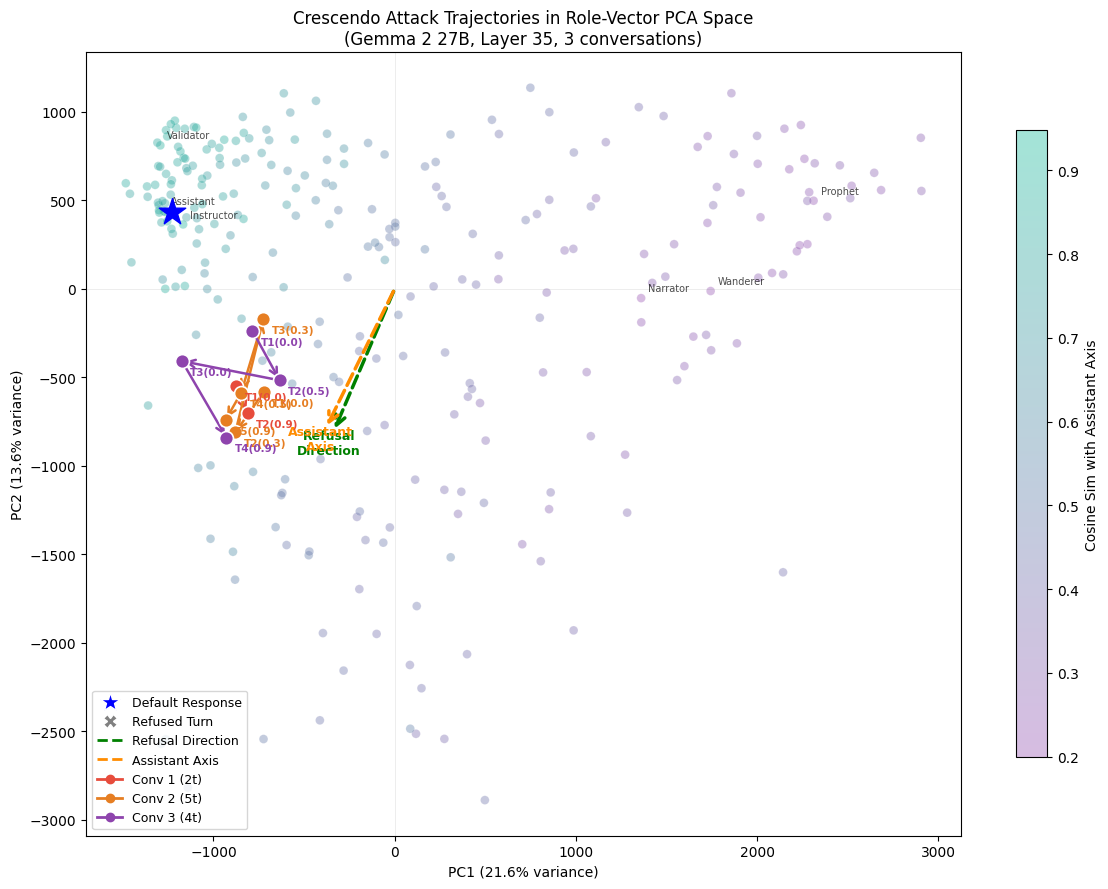

In [140]:
# --- Project all attack conversations into role-vector PCA space ---
#
# Role vectors on HuggingFace = E[h | role=r]  (raw mean activations)
# Response-mean activations from attack = same representation
# MeanScaler handles centering (subtracts role-vector mean)

if conversations:
    # Colors for different conversations
    conv_colors = ['#e74c3c', '#e67e22', '#8e44ad', '#2980b9', '#27ae60']

    # Color role vectors by actual assistant axis cosine similarity
    custom_cmap = LinearSegmentedColormap.from_list('PurpleTeal', ['#9b59b6', '#1abc9c'])
    c_norm = (role_aa_cosine_sims + 1) / 2

    fig, ax = plt.subplots(figsize=(12, 9))

    # Role vectors (background)
    sc = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                    c=c_norm, cmap=custom_cmap,
                    s=40, alpha=0.4, edgecolors='white', linewidth=0.3, zorder=2)

    # Default response
    ax.scatter(default_2d[0], default_2d[1], c='blue', marker='*', s=400, zorder=4)

    # Label extreme roles by assistant axis
    sorted_by_aa = np.argsort(role_aa_cosine_sims)
    for idx in list(sorted_by_aa[:3]) + list(sorted_by_aa[-3:]):
        label = role_labels[idx].replace('_', ' ').title()
        ax.annotate(label, xy=(pca_transformed[idx, 0], pca_transformed[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=7, alpha=0.7, zorder=3)

    # Plot each conversation as a trajectory
    for conv_idx, (conv_data, resp_acts) in enumerate(conversations):
        color = conv_colors[conv_idx % len(conv_colors)]

        turn_vecs, turn_labels, turn_scores, turn_refused = [], [], [], []
        for td in conv_data["turns"]:
            tn = td["turn"]
            if tn not in resp_acts:
                continue
            act = resp_acts[tn][TARGET_LAYER].float().numpy().reshape(1, -1)
            turn_vecs.append(act)
            turn_labels.append(f"T{tn}")
            turn_scores.append(td.get("objective_score") or 0.0)
            turn_refused.append(td.get("was_refused", False))

        if not turn_vecs:
            continue

        turn_vecs = np.concatenate(turn_vecs, axis=0)
        turn_scaled = scaler.transform(turn_vecs)
        turn_pca = pca.transform(turn_scaled)

        # Arrows
        for i in range(len(turn_pca) - 1):
            ax.annotate('', xy=(turn_pca[i+1, 0], turn_pca[i+1, 1]),
                        xytext=(turn_pca[i, 0], turn_pca[i, 1]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14),
                        zorder=5)

        # Markers + labels
        for i, (lbl, sc_val, ref) in enumerate(zip(turn_labels, turn_scores, turn_refused)):
            mkr = 'X' if ref else 'o'
            ax.scatter(turn_pca[i, 0], turn_pca[i, 1],
                       c=color, marker=mkr, s=100,
                       edgecolors='white' if not ref else 'darkred',
                       linewidth=1.2, zorder=6)
            status = "ref" if ref else f"{sc_val:.1f}"
            ax.annotate(f'{lbl}({status})',
                        xy=(turn_pca[i, 0], turn_pca[i, 1]),
                        xytext=(6, -10), textcoords='offset points',
                        fontsize=7.5, fontweight='bold', color=color, zorder=7)

    # Refusal direction (this IS a difference vector: harmful_mean - harmless_mean)
    refusal_dir = torch.load("../vectors/gemma-2-27b-it/refusal_mean_diffs.pt",
                             map_location="cpu", weights_only=True)
    metadata = json.load(open("../vectors/gemma-2-27b-it/metadata.json"))
    pos_idx = refusal_dir.shape[0] + metadata["pos"]
    refusal_at_layer = refusal_dir[pos_idx, TARGET_LAYER].float().numpy().reshape(1, -1)
    refusal_scaled = scaler.transform(refusal_at_layer)
    refusal_pca = pca.transform(refusal_scaled)[0]
    rn = np.sqrt(refusal_pca[0]**2 + refusal_pca[1]**2)
    if rn > 0:
        s = max(abs(pca_transformed[:, 0]).max(), abs(pca_transformed[:, 1]).max()) * 0.3
        ax.annotate('', xy=(refusal_pca[0]/rn*s, refusal_pca[1]/rn*s), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2.5,
                                    mutation_scale=18, linestyle='--'), zorder=4)
        ax.text(refusal_pca[0]/rn*s*1.08, refusal_pca[1]/rn*s*1.08, 'Refusal\nDirection',
                fontsize=9, color='green', fontweight='bold', ha='center', va='center', zorder=4)

    # Assistant axis arrow
    aa_scaled = scaler.transform(assistant_axis.reshape(1, -1))
    aa_pca = pca.transform(aa_scaled)[0]
    aa_rn = np.sqrt(aa_pca[0]**2 + aa_pca[1]**2)
    if aa_rn > 0:
        s = max(abs(pca_transformed[:, 0]).max(), abs(pca_transformed[:, 1]).max()) * 0.3
        ax.annotate('', xy=(aa_pca[0]/aa_rn*s, aa_pca[1]/aa_rn*s), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5,
                                    mutation_scale=18, linestyle='--'), zorder=4)
        ax.text(aa_pca[0]/aa_rn*s*1.08, aa_pca[1]/aa_rn*s*1.08, 'Assistant\nAxis',
                fontsize=9, color='darkorange', fontweight='bold', ha='center', va='center', zorder=4)

    plt.colorbar(sc, ax=ax, label='Cosine Sim with Assistant Axis', shrink=0.8)
    ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%} variance)')
    ax.set_title(f'Crescendo Attack Trajectories in Role-Vector PCA Space\n'
                 f'({MODEL_NAME.replace("-", " ").title()}, Layer {TARGET_LAYER}, '
                 f'{len(conversations)} conversations)')
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.2)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.2)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='blue', markersize=15, label='Default Response'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', markersize=10, label='Refused Turn'),
        Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='Refusal Direction'),
        Line2D([0], [0], color='darkorange', linewidth=2, linestyle='--', label='Assistant Axis'),
    ]
    for ci in range(min(len(conversations), len(conv_colors))):
        legend_elements.append(
            Line2D([0], [0], color=conv_colors[ci], linewidth=2, marker='o',
                   markerfacecolor=conv_colors[ci], markersize=6,
                   label=f'Conv {ci+1} ({conversations[ci][0]["n_turns"]}t)')
        )
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping — no Gemma 2 runs with response activations found.")

## Layer-wise Cosine Similarity: Refusal Direction vs Assistant Axis

Check whether the refusal direction aligns with or opposes the assistant axis at each layer.

In [ ]:
# Load refusal mean diffs and assistant axis for all layers
refusal_mean_diffs = torch.load("../vectors/gemma-2-27b-it/refusal_mean_diffs.pt",
                                map_location="cpu", weights_only=True)
metadata = json.load(open("../vectors/gemma-2-27b-it/metadata.json"))
pos_idx = refusal_mean_diffs.shape[0] + metadata["pos"]

aa_data = torch.load("../vectors/gemma-2-27b-it/assistant_axis.pt",
                      map_location="cpu", weights_only=False)
if isinstance(aa_data, dict):
    aa_all_layers = aa_data["axis"].float()
else:
    aa_all_layers = aa_data.float()

n_layers = refusal_mean_diffs.shape[1]
cos_sims = []
refusal_norms = []
aa_norms = []

for layer in range(n_layers):
    r = refusal_mean_diffs[pos_idx, layer].float()
    a = aa_all_layers[layer]
    cos = torch.nn.functional.cosine_similarity(r.unsqueeze(0), a.unsqueeze(0)).item()
    cos_sims.append(cos)
    refusal_norms.append(r.norm().item())
    aa_norms.append(a.norm().item())

cos_sims = np.array(cos_sims)
layers = np.arange(n_layers)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Cosine similarity
colors = ['#e74c3c' if c < 0 else '#27ae60' for c in cos_sims]
ax1.bar(layers, cos_sims, color=colors, alpha=0.7, width=0.8)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(metadata["layer"], color='blue', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Selected refusal layer ({metadata["layer"]})')
ax1.set_ylabel('Cosine Similarity')
ax1.set_title(f'Refusal Direction vs Assistant Axis (pos={metadata["pos"]}, per layer)\n'
              f'Green = aligned (refusal ≈ assistant), Red = anti-aligned')
ax1.set_ylim(-0.6, 0.6)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Norms
ax2.plot(layers, refusal_norms, label='Refusal direction norm', color='green', linewidth=1.5)
ax2.plot(layers, aa_norms, label='Assistant axis norm', color='darkorange', linewidth=1.5)
ax2.set_xlabel('Layer')
ax2.set_ylabel('Norm')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print key values
print(f"\nSelected layer {metadata['layer']}: cos = {cos_sims[metadata['layer']]:.4f}")
peak_pos = np.argmax(cos_sims)
peak_neg = np.argmin(cos_sims)
print(f"Most aligned:      layer {peak_pos}, cos = {cos_sims[peak_pos]:.4f}")
print(f"Most anti-aligned: layer {peak_neg}, cos = {cos_sims[peak_neg]:.4f}")
print(f"Sign flip occurs around layer {np.where(np.diff(np.sign(cos_sims)))[0]}")